# 🧪 Taller - Segmentación Semántica con DeepLabV3

Este notebook aplica segmentación semántica sobre una imagen utilizando el modelo DeepLabV3-ResNet101 de `torchvision`. El objetivo es generar una máscara que identifique diferentes clases (persona, auto, perro, etc.) y visualizarla en colores.


In [1]:
# Instalar librerías necesarias (solo si usas localmente)
!pip install pillow matplotlib torchvision


In [2]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os


In [3]:
# Cargar modelo DeepLabV3 preentrenado
model = models.segmentation.deeplabv3_resnet101(pretrained=True).eval()


c:\Users\judar\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\judar\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to C:\Users\judar/.cache\torch\hub\checkpoints\deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:05<00:00, 40.9MB/s] 


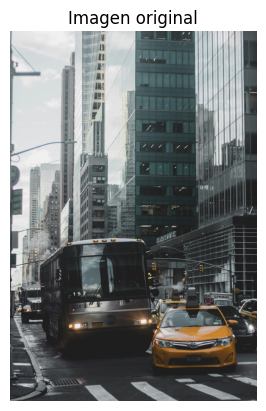

In [20]:
# Ruta de la imagen de entrada
input_image_path = "../imagenes_entrada/imagen3.jpg"  # Reemplaza con la ruta correcta

# Cargar imagen y convertir a RGB
input_image = Image.open(input_image_path).convert("RGB")

# Mostrar imagen original
plt.imshow(input_image)
plt.title("Imagen original")
plt.axis("off")
plt.show()


In [21]:
# Transformaciones necesarias
preprocess = transforms.Compose([
    transforms.Resize(520),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(input_image).unsqueeze(0)


In [22]:
# Aplicar el modelo
with torch.no_grad():
    output = model(input_tensor)['out'][0]

# Obtener predicciones
output_predictions = output.argmax(0).byte().cpu().numpy()


In [23]:
# Función para decodificar los valores de clases a colores
def decode_segmap(image, nc=21):
    label_colors = np.array([
        (0, 0, 0), (128, 0, 0), (0, 128, 0), (128, 128, 0), (0, 0, 128),
        (128, 0, 128), (0, 128, 128), (128, 128, 128), (64, 0, 0),
        (192, 0, 0), (64, 128, 0), (192, 128, 0), (64, 0, 128),
        (192, 0, 128), (64, 128, 128), (192, 128, 128), (0, 64, 0),
        (128, 64, 0), (0, 192, 0), (128, 192, 0), (0, 64, 128)
    ])
    r = np.zeros_like(image).astype(np.uint8)
    g = np.zeros_like(image).astype(np.uint8)
    b = np.zeros_like(image).astype(np.uint8)

    for l in range(0, nc):
        idx = image == l
        r[idx] = label_colors[l, 0]
        g[idx] = label_colors[l, 1]
        b[idx] = label_colors[l, 2]

    rgb = np.stack([r, g, b], axis=2)
    return rgb

# Decodificar
decoded = decode_segmap(output_predictions)


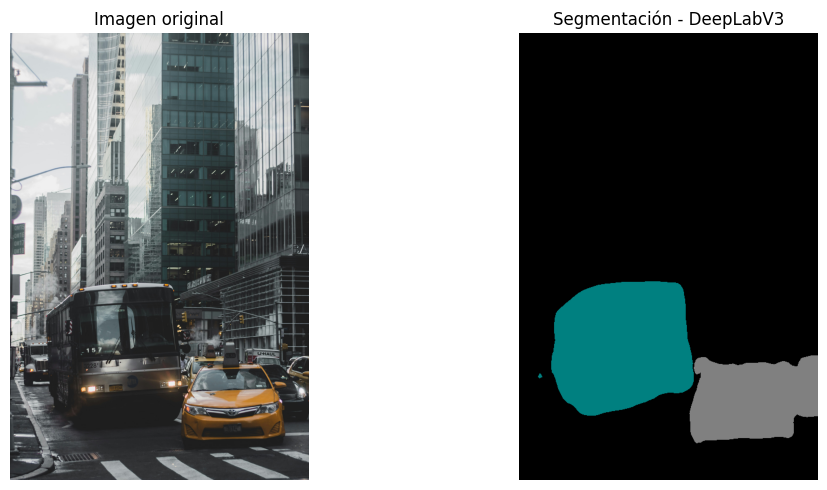

In [24]:
# Mostrar resultados
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(input_image)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(decoded)
plt.title("Segmentación - DeepLabV3")
plt.axis("off")

plt.tight_layout()
plt.show()


In [25]:
# Crear carpetas si no existen
os.makedirs("mascaras_salida", exist_ok=True)
os.makedirs("resultados", exist_ok=True)

# Guardar máscara (grises) y segmentación coloreada
Image.fromarray(output_predictions).save("mascaras_salida/mask3.png")
Image.fromarray(decoded).save("resultados/imagen_segmentada_colores3.png")
print("Máscaras guardadas correctamente.")


Máscaras guardadas correctamente.
